In [7]:
# from lcLevy.CRaw3. import*
from lcLevy.Image import Img
import skimage
import matplotlib.pyplot as plt
import numpy as np

In [8]:
img = Img("EOS_R100/IMG_0004.CR3")

In [9]:
print(img.cr3)

{b'CNCV': b'CanonCR3_001/00.09.00/00.00.00', b'CTBO': {1: ctbo_line(index=1, offset=26168, size=65560), 2: ctbo_line(index=2, offset=91728, size=283976), 3: ctbo_line(index=3, offset=375704, size=33224880), 4: ctbo_line(index=4, offset=0, size=0), 5: ctbo_line(index=5, offset=0, size=0)}, b'CMT1': (320, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x0000019853B9A660>), b'CMT2': (712, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x0000019853B20F50>), b'CMT3': (1840, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x0000019853BA5BD0>), b'CMT4': (7592, <lcLevy.CRaw3.TiffIfd.TiffIfd object at 0x0000019855EB9A70>), b'THMB': (9408, thmb(w=160, h=120, size=14479)), 'trak1': {b'CRAW': craw(w=6000, h=4000, bits=24), b'stsz': [2156405], b'co64': [375720]}, 'trak2': {b'CMP1': cmp1(iw=1624, ih=1080, tw=1624, th=1080, d=14, p=4, cfa=1, extra=0, wl=0, b35=0, hsize=112), b'CRAW': craw(w=1624, h=1080, bits=24), b'stsz': [1637008], b'co64': [2532128]}, 'trak3': {b'CMP1': cmp1(iw=6288, ih=4056, tw=3144, th=4056, d=14, p=

In [ ]:
crx = img.big_crx
# the stuff we have to play with
crx.display_tiles()
crx.display_planes()
crx.display_subbands()
# current plan is to figure out how to image all the components of these separately
# Then maybe put them together. 
# might be better to just go for the altogether first 

0 0x003f9e88 0x00379278 0 1 0
0 0x00773100 0x00383cc0 1 1 0
0 0x00af6dc0 0x00383d48 2 1 0
0 0x00e7ab08 0x003722f0 3 1 0
1 0x011ecdf8 0x0037c418 0 1 0
1 0x01569210 0x003956c0 1 1 0
1 0x018fe8d0 0x003955f0 2 1 0
1 0x01c93ec0 0x0036c5e0 3 1 0


In [ ]:
print(crx.subbands)
# this guy has important stuff about image size
print(crx.cmp1)

{0: {0: {0: crx_subband(index=0, offset=4169352, size=3641976, supportsPartial=0, quantValue=4, val_19bits=0)}, 1: {0: crx_subband(index=0, offset=7811328, size=3685568, supportsPartial=0, quantValue=4, val_19bits=4)}, 2: {0: crx_subband(index=0, offset=11496896, size=3685704, supportsPartial=0, quantValue=4, val_19bits=4)}, 3: {0: crx_subband(index=0, offset=15182600, size=3613424, supportsPartial=0, quantValue=4, val_19bits=7)}}, 1: {0: {0: crx_subband(index=0, offset=18796024, size=3654680, supportsPartial=0, quantValue=4, val_19bits=4)}, 1: {0: crx_subband(index=0, offset=22450704, size=3757760, supportsPartial=0, quantValue=4, val_19bits=7)}, 2: {0: crx_subband(index=0, offset=26208464, size=3757552, supportsPartial=0, quantValue=4, val_19bits=3)}, 3: {0: crx_subband(index=0, offset=29966016, size=3589600, supportsPartial=0, quantValue=4, val_19bits=3)}}}
cmp1(iw=6288, ih=4056, tw=3144, th=4056, d=14, p=4, cfa=0, extra=0, wl=0, b35=0, hsize=216)


In [ ]:
# let's pull out some planes, why not!
data = crx.data
subb = crx.subbands
base = crx.base

# What actually goes on in the subbands?? who knows 
# may be good to check out the planes?


  # for all subbands 
# for _, v in len(crx.subbands.items()):
#     for _, v2 in v.items():
#         for v3 in v2.values():
#             print(f"{v}, {v2}, {v3}")



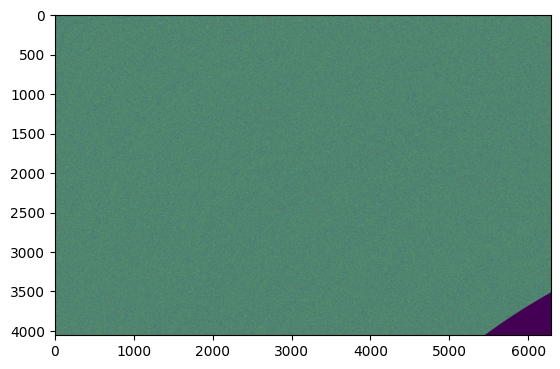

In [ ]:
# This doesn't seem right
# figure out amount of data allocated to each pixel
# is this even how it is layed out??
first_band = subb[0][2][0]
start = first_band.offset-base
size = first_band.size

photo = []

chunk_size = 1
for j in range(4056):
    photo.append([])
    for i in range(6288):
        photo[j].append(int.from_bytes(data[start+chunk_size*i*j:start+chunk_size*(i*j+1)]))
plt.imshow(photo)



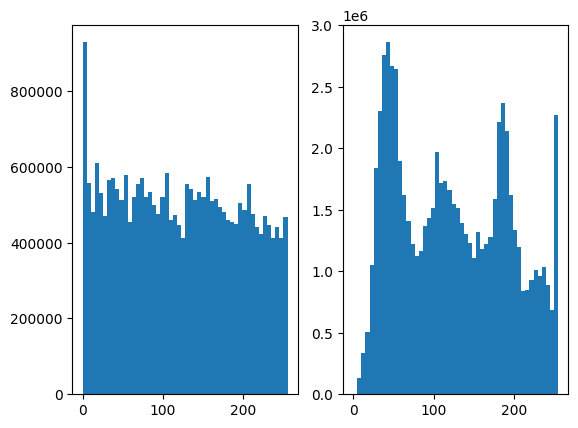

In [ ]:
# Ideally these will be similar as we have a similar number of pixels at each brightness
# then again, maybe that's not what the subbands are for

# print(np.pow(2,63))
fix, ax = plt.subplots(1,2)
np_arr= np.array(photo)
ax[0].hist(np_arr.flatten(), bins = 50)

real_img = skimage.io.imread("EOS_R100/IMG_0004.JPG")
ax[1].hist(np.ndarray.flatten(real_img), bins = 50)
plt.show()